<a href="https://colab.research.google.com/github/leewei1702/Computer-Game-Programming/blob/main/AI_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Steam Store Reviews Analysis**


## Installation

In [ ]:
pip install nltk

In [ ]:
pip install pandas

In [ ]:
import nltk
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [ ]:
pip install scikit-learn

In [ ]:
pip install "numpy<2.0.0" spacy

In [ ]:
pip install transformers

## Import Packages

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from google.colab import files
import re
import time
import requests
import datetime
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import spacy
import seaborn as sns
import matplotlib.pyplot as plt
import transformers

## Main Code

### Web Scraping

In [ ]:
def fetch_reviews(app_id, total_reviews):
    all_reviews = []
    cursor = '*'

    while len(all_reviews) < total_reviews:
        url = f"https://store.steampowered.com/appreviews/{app_id}"
        params = {
            'json': 1,
            'filter': 'recent',
            'language': 'english',
            'review_type': 'all',
            'purchase_type': 'all',
            'cursor': cursor,
            'num_per_page': 100
        }

        response = requests.get(url, params=params)
        data = response.json()
        reviews = data.get('reviews', [])

        for r in reviews:
            review_text = r['review'].strip()         #This will removes any leading and trailing whitespaces in the review
            if review_text:                           #The review row will only be appended if the review is not blank
                all_reviews.append({
                    'ReviewText': review_text,
                    'ReviewLength': len(review_text),
                    'Recommended': r['voted_up'],
                    'PlayHours': r['author']['playtime_forever'] / 60,
                    'ReviewDate': datetime.datetime.fromtimestamp(r['timestamp_created']).strftime('%Y-%m-%d %H:%M:%S')
                })

            if len(all_reviews) >= total_reviews:
                break

        cursor = data.get('cursor')
        time.sleep(1) #Can set this to lower value to generate faster, but be warned that steam might temporarily block you

    return pd.DataFrame(all_reviews)

app_id = 730  #Can change this to another steam game id
total_reviews = 100   #Can change the number of reviews generated
df = fetch_reviews(app_id, total_reviews)

df.head(total_reviews)
#Uncomment the code below to download the reviews as csv format
#df.to_csv('steam_reviews.csv', index=False)
#files.download('steam_reviews.csv')

,ReviewText,ReviewLength,Recommended,PlayHours,ReviewDate
0,good game nice knives !,23,True,8.600000,2025-04-29 07:15:19
1,i hate this game\n10/10,22,True,499.833333,2025-04-29 07:14:59
2,I LIKE I \T\\,13,True,9.433333,2025-04-29 07:13:23
3,its fun,7,True,76.416667,2025-04-29 07:12:43
4,KAL!!!!!,8,False,114.666667,2025-04-29 07:10:11
...,...,...,...,...,...
95,hard but fun,12,True,18.416667,2025-04-29 00:14:39
96,hacker city,11,False,87.816667,2025-04-29 00:07:57
97,"This game has a cheating problem, but at least...",619,False,506.000000,2025-04-28 23:59:03
98,fun game,8,True,7.083333,2025-04-28 23:54:49


### Data Preprocessing

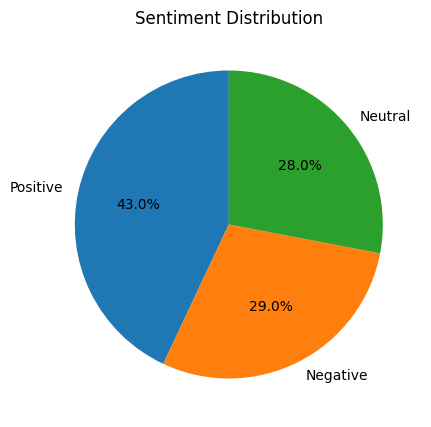

,ReviewText,ReviewLength,Recommended,PlayHours,ReviewDate,Cleaned_Review,Sentiment
0,good game nice knives !,23,True,8.600000,2025-04-29 07:15:19,good game nice knife,Positive
1,i hate this game\n10/10,22,True,499.833333,2025-04-29 07:14:59,hate game,Negative
2,I LIKE I \T\\,13,True,9.433333,2025-04-29 07:13:23,I like I t,Positive
3,its fun,7,True,76.416667,2025-04-29 07:12:43,fun,Positive
4,KAL!!!!!,8,False,114.666667,2025-04-29 07:10:11,kal,Neutral
...,...,...,...,...,...,...,...
95,hard but fun,12,True,18.416667,2025-04-29 00:14:39,hard fun,Positive
96,hacker city,11,False,87.816667,2025-04-29 00:07:57,hacker city,Neutral
97,"This game has a cheating problem, but at least...",619,False,506.000000,2025-04-28 23:59:03,this game cheating problem least path of exile...,Negative
98,fun game,8,True,7.083333,2025-04-28 23:54:49,fun game,Positive


In [ ]:
#Text cleaning (removing stop words/punctuation/special characters/numbers, lowercase)
stop = stopwords.words('english')
df['Cleaned_Review'] = df['ReviewText'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)])).apply(lambda x:re.sub(r'[^\w\s]', '', x)).apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x)).apply(lambda x: x.lower())

#Tokenization and lemmatization
nlp = spacy.load('en_core_web_sm')                #uses spacy
def lemmatization(text):
    doc = nlp(text)                               #Tokenization
    lemmatized = [token.lemma_ for token in doc]  #Lemmatization
    return ' '.join(lemmatized)

df['Cleaned_Review'] = df['Cleaned_Review'].apply(lemmatization)

#Feature extraction (e.g., TF-IDF, word embeddings using Word2Vec or BERT)
#TF-IDF
cv_tfidf = TfidfVectorizer(stop_words="english")
X_tfidf = cv_tfidf.fit_transform(df['Cleaned_Review'])
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=cv_tfidf.get_feature_names_out())

#Divide into negative, neutral, positive
sia = SentimentIntensityAnalyzer()

def getSentiment(text):
  score = sia.polarity_scores(text)
  if score['compound'] >= 0.05:
    return 'Positive'
  elif score['compound'] <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(getSentiment)

value_counts = df['Sentiment'].value_counts()
value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(5, 5))
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()
df

#Uncomment the code below to download the cleaned reviews as csv format
#df.to_csv('steam_reviews.csv', index=False)
#files.download('steam_reviews.csv')

#Uncomment the code below to download the reviews feature extraction as csv format
#df_tfidf.to_csv('steam_reviews_feature_extraction.csv', index=False)
#files.download('steam_reviews_feature_extraction.csv')


### Sentiment Analysis (Each Member)

#### Naïve Bayes

Accuracy: 0.6066666666666667

Confusion Matrix:
 [[ 67  10  75]
 [  2  37 141]
 [  4   4 260]]

Classification Report:
               precision    recall  f1-score   support

    Negative       0.92      0.44      0.60       152
     Neutral       0.73      0.21      0.32       180
    Positive       0.55      0.97      0.70       268

    accuracy                           0.61       600
   macro avg       0.73      0.54      0.54       600
weighted avg       0.69      0.61      0.56       600



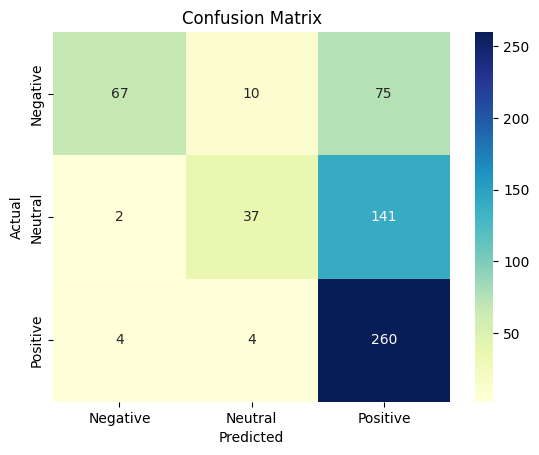

In [ ]:
X = X_tfidf
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

labels = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Type 'exit' to quit.
Enter your review: i dislike this game


Type 'exit' to quit.
Enter your review: exit




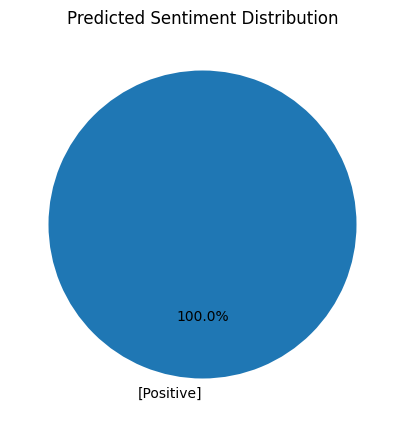

,Input,Cleaned Input,Prediction
0,i dislike this game,dislike game,[Positive]


In [ ]:
def preprocess_input(review):
  stop = stopwords.words('english')
  review = review.lower()
  review = ' '.join([word for word in review.split() if word not in (stop)])
  review = re.sub(r'[^\w\s]', '', review)
  review = re.sub(r'[^a-zA-Z\s]', '', review)
  review = lemmatization(review)
  return review

inputList = []
cleanedInputList = []
predictionList = []

while True:
  print("Type 'exit' to quit.")
  userInput = input("Enter your review: ")
  print("\n")
  if userInput.lower() == 'exit':
    break

  cleanedInput = preprocess_input(userInput)

  X_input = cv_tfidf.transform([cleanedInput])

  prediction = nb.predict(X_input)

  inputList.append(userInput)
  cleanedInputList.append(cleanedInput)
  predictionList.append(prediction)

results_df = pd.DataFrame({'Input': inputList, 'Cleaned Input': cleanedInputList, 'Prediction': predictionList})
value_counts = results_df['Prediction'].value_counts()
value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(5, 5))
plt.title('Predicted Sentiment Distribution')
plt.ylabel('')
plt.show()
results_df

#### Support Vector Machine

#### Transformer-based Model

In [ ]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")
data = df['ReviewText'].tolist()
results = sentiment_pipeline(data)


output = []
for i, result in enumerate(results):
  output.append({
      "ReviewText": data[i],
      "Sentiment": result['label'],
      "Score": result['score']
  })

results_df = pd.DataFrame(output)

results_df

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


,ReviewText,Sentiment,Score
0,Good game that you will play with all walks of...,POSITIVE,0.999801
1,yea,POSITIVE,0.772058
2,I was just in a game with 6 cheaters. It was f...,POSITIVE,0.999854
3,gold gold gold,POSITIVE,0.999807
4,"I lost my job, my life, my money, my girl and ...",POSITIVE,0.998989
...,...,...,...
95,:),POSITIVE,0.648929
96,Brain rot,NEGATIVE,0.999791
97,it is a good and fun game,POSITIVE,0.999884
98,something something noobs down,NEGATIVE,0.992472
